In [20]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Marina\genres\ast_model\wandb_logs\\0wandb_hyperparams.csv")
df.head()

,Name,State,Created,freeze_layers,eval/accuracy,batch_size,normalisation,activation_fn,dropout_top,learning_rate
0,trial_28,finished,2025-07-23T07:42:12.000Z,7,0.618932,4,layer,none,0.168915,0.000013
1,trial_27,finished,2025-07-23T07:35:05.000Z,8,0.626214,4,none,none,0.268479,0.000028
2,trial_26,finished,2025-07-23T07:27:57.000Z,5,0.628641,4,none,none,0.190879,0.000026
3,trial_25,finished,2025-07-23T07:14:36.000Z,8,0.633495,4,layer,relu,0.275924,0.000057
4,trial_23,finished,2025-07-23T06:03:43.000Z,7,0.640777,4,layer,none,0.329332,0.000016


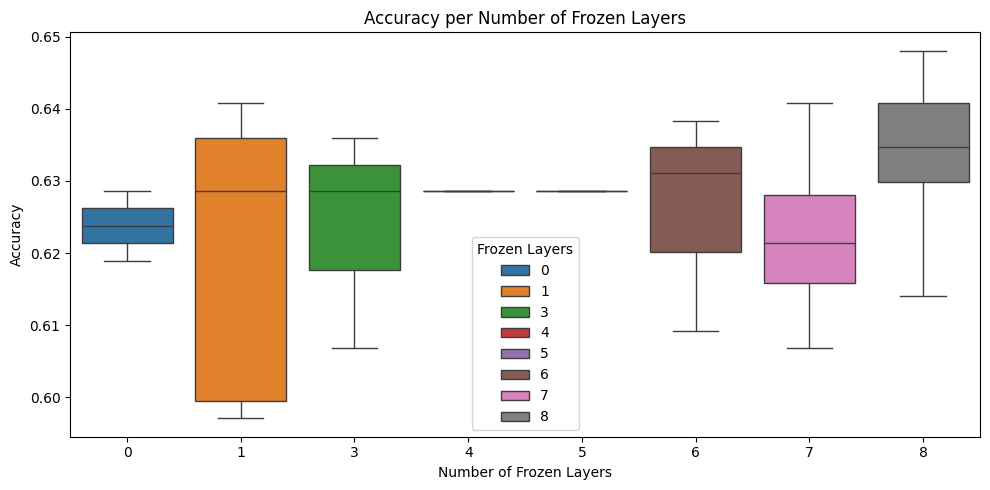

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
#df['hyperparams.freeze_layers'] = df['hyperparams.freeze_layers'].astype(str)  # or use Categorical if you want specific order

# Create the plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='freeze_layers', y='eval/accuracy', hue='freeze_layers',  palette='tab10')

# Adjust plot
plt.xlabel("Number of Frozen Layers")
plt.ylabel("Accuracy")
plt.title("Accuracy per Number of Frozen Layers")
plt.legend(title="Frozen Layers")
plt.tight_layout()
plt.show()

C:\Users\Marina\AppData\Local\Temp\ipykernel_17284\744773637.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Frozen Layers")


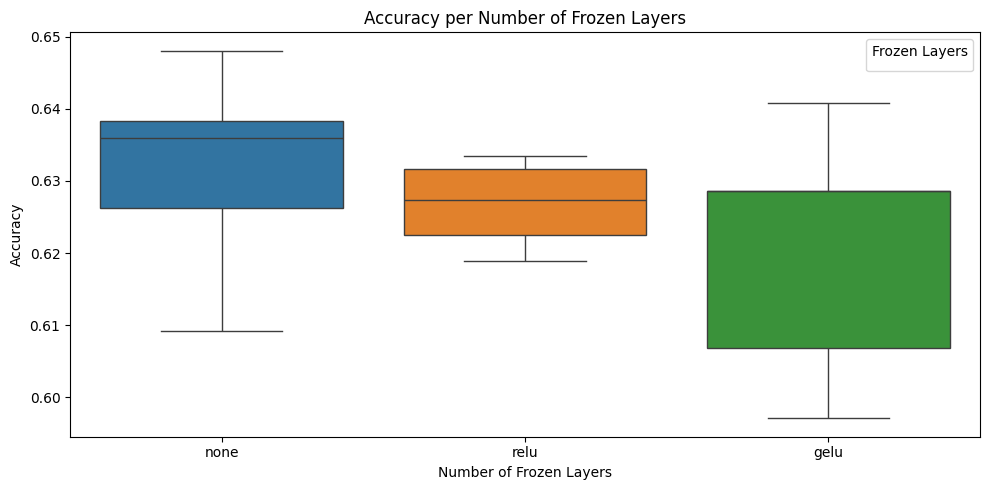

In [26]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='activation_fn', y='eval/accuracy', hue='activation_fn',  palette='tab10')

# Adjust plot
plt.xlabel("Number of Frozen Layers")
plt.ylabel("Accuracy")
plt.title("Accuracy per Number of Frozen Layers")
plt.legend(title="Frozen Layers")
plt.tight_layout()
plt.show()

C:\Users\Marina\AppData\Local\Temp\ipykernel_17284\3007680202.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=[str(k) for k in df[col].unique()])
C:\Users\Marina\AppData\Local\Temp\ipykernel_17284\3007680202.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=[str(k) for k in df[col].unique()])
C:\Users\Marina\AppData\Local\Temp\ipykernel_17284\3007680202.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=[str(k) for k in df[col].unique()])


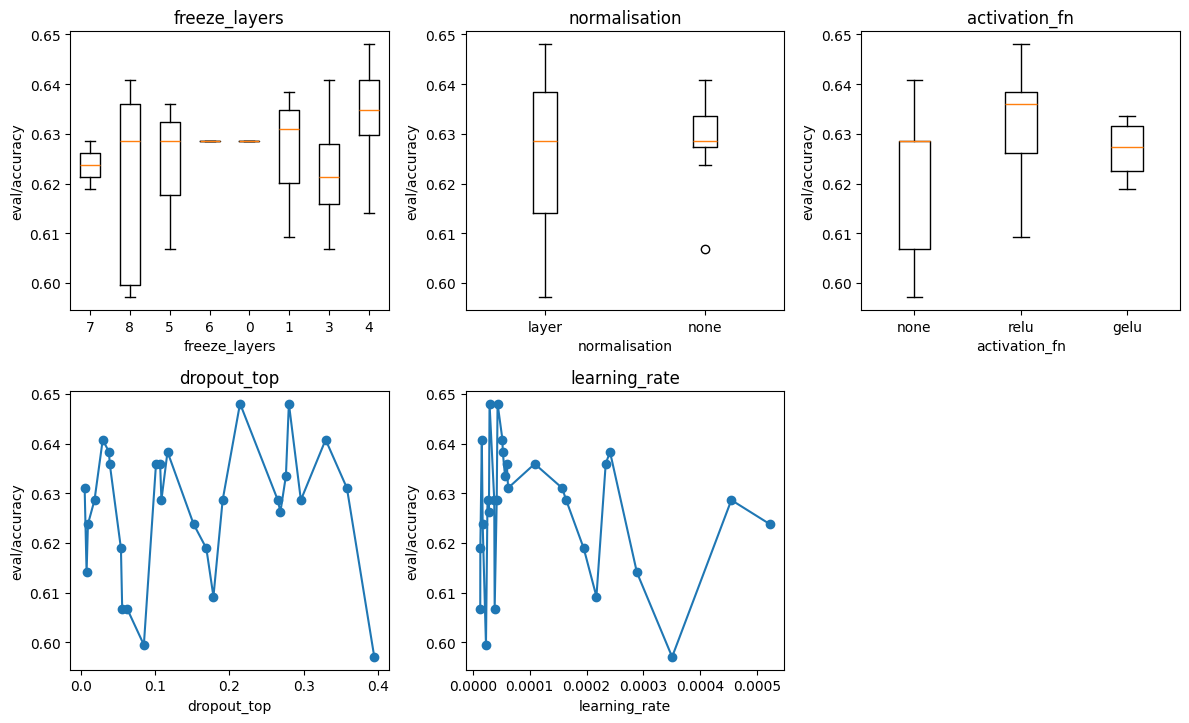

In [22]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# df should have: ["freeze_layers","normalisation","activation_fn","dropout_top",
#                  "learning_rate","accuracy"]
df['freeze_layers'] = df['freeze_layers'].astype(str) 
params = ["freeze_layers","normalisation","activation_fn","dropout_top","learning_rate"]
n = len(params)
rows = cols = math.ceil(math.sqrt(n))

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3.5*rows))
axes = axes.flatten()

def plot_param(ax, df, col):
    y = "eval/accuracy"
    if pd.api.types.is_numeric_dtype(df[col]):
        ax.scatter(df[col], df[y])
        # optional: running mean to see trend
        df_sorted = df.sort_values(col)
        rolling = df_sorted[y].rolling(window=max(1,len(df)//20), min_periods=1).mean()
        ax.plot(df_sorted[col], rolling)
        ax.set_xlabel(col)
        ax.set_ylabel(y)
    else:
        # categorical: show boxplots (or strip)
        groups = [g[y].values for _, g in df.groupby(col)]
        ax.boxplot(groups, labels=[str(k) for k in df[col].unique()])
        ax.set_xlabel(col)
        ax.set_ylabel(y)
    ax.set_title(col)

for i, p in enumerate(params):
    plot_param(axes[i], df, p)

# remove empty axes (if any)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()


In [23]:
import pandas as pd
from scipy import stats
from sklearn.feature_selection import mutual_info_regression

y = df["eval/accuracy"].values
num = ["learning_rate", "dropout_top", "freeze_layers"]  # if numeric
cat = ["normalisation", "activation_fn"]

# Spearman
spearman = {c: stats.spearmanr(df[c], y, nan_policy="omit").correlation for c in num}

# Mutual information (handles non-linear)
mi = mutual_info_regression(df[num], y, random_state=0)
mi = dict(zip(num, mi))

# ANOVA eta-squared for categorical
def eta_squared(cat_col):
    groups = [g["eval/accuracy"].values for _, g in df.groupby(cat_col)]
    f, p = stats.f_oneway(*groups)
    ss_between = sum(len(g)*((g.mean()-y.mean())**2) for g in groups)
    ss_total = ((y - y.mean())**2).sum()
    return ss_between/ss_total
etas = {c: eta_squared(c) for c in cat}


In [24]:
etas

{'normalisation': 0.014551465274287667, 'activation_fn': 0.15479270548776905}

In [25]:
spearman

{'learning_rate': -0.00769554873423945,
 'dropout_top': 0.10801252330557512,
 'freeze_layers': 0.32473848817975515}